In [332]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold

In [333]:
np.random.seed(0)

In [334]:
#Dogs
dogs_wl = np.random.normal(loc=5, scale=1, size=10)
dogs_efi=np.random.normal(loc=8, scale=1, size=10)

In [335]:
#Cats
cats_wl=np.random.normal(loc=8, scale=1, size=10)
cats_efi=np.random.normal(loc=5,scale=1 ,size=10)

In [336]:
#combining data(putting data in a vertical arrangement as that of 1D)
dogs_data=np.vstack((dogs_wl,dogs_efi)).T
cats_data=np.vstack((cats_wl,cats_efi)).T
data=np.vstack((dogs_data,cats_data))
labels=np.vstack((np.zeros(len(dogs_data)),np.ones(len(cats_data))))

### Labels
#### if label is 0, it is a DOG (DOG=0)
#### if label is 1, it is a CAT (CAT=1)

In [337]:
labels

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

we had done size=10 in np.randomnormal(loc,scale,size) , that is why 10 data points have come in the array , and we had put scale=1(which means 1D arrangement is made).

In [338]:
#Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(data, labels.ravel(), test_size=0.2, random_state=42)

In [339]:
x_test

array([[6.76405235, 8.14404357],
       [7.81281615, 6.20237985],
       [6.54563433, 5.15634897],
       [5.40015721, 9.45427351]])

In [340]:
x_train

array([[ 4.89678115,  8.3130677 ],
       [ 4.02272212,  8.33367433],
       [ 8.6536186 ,  5.37816252],
       [ 7.2408932 ,  8.12167502],
       [ 9.53277921,  4.61267318],
       [ 8.04575852,  6.23029068],
       [ 7.25783498,  3.01920353],
       [ 5.97873798,  8.76103773],
       [ 5.4105985 ,  7.14590426],
       [ 9.46935877,  4.69769725],
       [ 6.86755799,  8.44386323],
       [ 8.8644362 ,  4.11221425],
       [ 4.84864279,  7.79484174],
       [ 5.44701018,  5.15494743],
       [10.26975462,  4.65208785],
       [ 5.95008842,  9.49407907]])

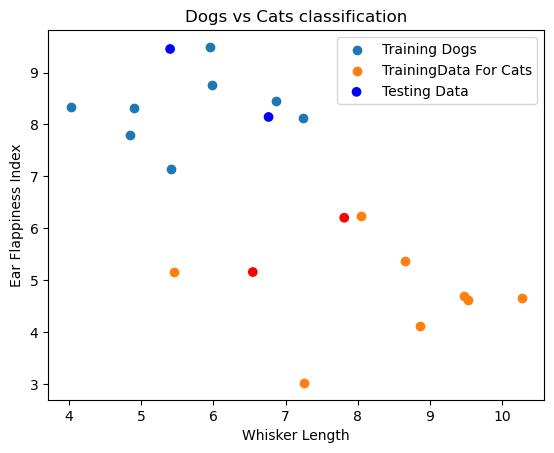

In [341]:
#Plotting training and testing data points
plt.scatter(x_train[y_train==0][:,0],x_train[y_train==0][:,1], label='Training Dogs' )
plt.scatter(x_train[y_train==1][:,0],x_train[y_train==1][:,1],label='TrainingData For Cats')
plt.scatter(x_test[:,0],x_test[:,1],c=y_test,cmap='bwr',label='Testing Data')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dogs vs Cats classification')
plt.legend()
plt.show()

In [342]:
#Implementing random linear classifier algorithm
def random_linear_classifier(data_dogs,data_cats,k,d):
    best_error=float('inf')
    best_theta=None
    best_theta0=None

    for i in range(k):
        theta=np.random.normal(size=d)
        theta0=np.random.normal()

        error = compute_error(data_dogs,data_cats,theta,theta0)

        if error < best_error:
            best_error=error
            best_theta=theta
            best_theta0=theta0

    return best_theta,best_theta0,best_error

def compute_error(data_dogs,data_cats,theta,theta0):
    error = 0
    for x_dog in data_dogs:
        if np.dot(theta,x_dog) + theta0 <= 0:
            error += 1
    for x_cat in data_cats:
        if np.dot(theta,x_cat) + theta0 > 0:
            error += 1
    return error
#dot product is used to calculate the linear combination of the input features (x_dog or x_cat) and the weight vector (theta). The result is then compared to the threshold (theta0) to determine if the classification is correct or not. If the classification is incorrect, the error count is incremented.
#dot keyword is used to calculate the dot product of two arrays. In this case, it calculates the dot product of the weight vector (theta) and the input feature vector (x_dog or x_cat). The dot product is a mathematical operation that combines the two vectors and produces a scalar value. This scalar value is then compared to the threshold (theta0) to determine if the classification is correct or not.

#define function for k-fold cross-vallidation
def cross_validates(data_dogs,data_cats,k_values,d,n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    avg_errors =[]

    for k in k_values:
        errors = []

        for train_index, val_index in kf.split(data_dogs):
            x_train_fold = np.vstack((data_dogs[train_index], data_cats[train_index]))
            y_train_fold = np.hstack((np.zeros(len(train_index)), np.ones(len(train_index))))
            x_val_fold = np.vstack((data_dogs[val_index], data_cats[val_index]))
            y_val_fold = np.hstack((np.zeros(len(val_index)), np.ones(len(val_index))))
                                                                    
            best_theta_fold, best_theta0_fold, error= random_linear_classification(x_train_fold[y_train_fold==0], x_train_fold[y_train_fold==1], k, d)
            errors.append(compute_error(x_val_fold[y_val_fold==0], x_val_fold[y_val_fold==1], best_theta_fold, best_theta0_fold))

        avg_errors.append(np.mean(errors))

    best_k = k_values[np.argmin(avg_errors)]
    return best_k

k_values = [1,10,150,100,200, 350]

In [343]:
best_k = cross_validates(dogs_data, cats_data, k_values, d=2)

In [344]:
print("Best k value:", best_k)

Best k value: 150


In [345]:
#run random linear classifier on trained dataset
# k is the no. of ittirations 
# d is the number of features
k = best_k
d = 2
best_theta_train, best_theta0_train, train_error = random_linear_classifier(x_train[y_train==0], x_train[y_train==1],k,d)

In [346]:
print("best_theta_train:", best_theta_train)
print("best_theta0_train:", best_theta0_train)

best_theta_train: [-0.11306645  0.18135584]
best_theta0_train: -0.5761479873330345


In [347]:
#Plot the decision boundary of training data
x_vals_train = np.linspace(2, 10, 100)
y_vals_train = (-best_theta_train[0] / best_theta_train[1]) * x_vals_train - (best_theta0_train / best_theta_train[1])

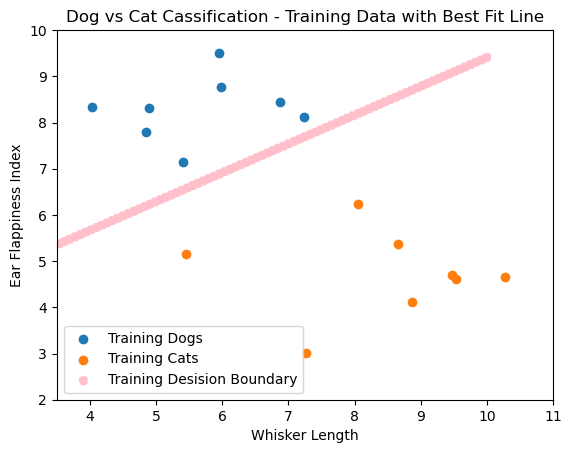

In [348]:
plt.scatter(x_train[y_train == 0 ][:,0], x_train[y_train == 0][:,1], label = 'Training Dogs')
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:,1], label = 'Training Cats')
plt.scatter(x_vals_train, y_vals_train, color = 'pink', linestyle = '--', label = 'Training Desision Boundary')

#Set same limits for the x and y axis

plt.xlim([3.5,11])
plt.ylim([2,10])
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dog vs Cat Cassification - Training Data with Best Fit Line')
plt.legend()
plt.show()

In [349]:
print("Training Error : ", train_error)

Training Error :  0


In [350]:
#Compute testing error

test_error = compute_error(x_test[y_test == 0], x_test[y_test == 1], best_theta_train, best_theta0_train )
print("Testing Error : ", test_error)


Testing Error :  0


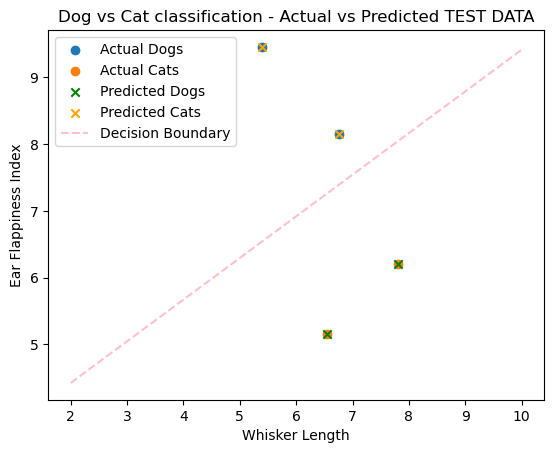

In [351]:
#Plot the actual test data and predicted test data


plt.scatter(x_test[y_test == 0][:,0], x_test[y_test == 0][:, 1], label = 'Actual Dogs')
plt.scatter(x_test[y_test == 1][:,0], x_test[y_test == 1][:, 1], label = 'Actual Cats')

#Plot test data points using decision boundary

predicted_labels = np.zeros_like(y_test)
for m, x_sample in enumerate(x_test):
    if np.dot(best_theta_train, x_sample) + best_theta0_train > 0:
        predicted_labels[m] = 1

#Plot predicted test data points
def new_func():
    plt.scatter(x_test[predicted_labels == 0][:,0], marker = 'x', label = 'Predicted Dogs', color = 'green')

plt.scatter(x_test[predicted_labels == 0][:,0], x_test[predicted_labels == 0][:,1], marker='x', label='Predicted Dogs', color='green')

plt.scatter(x_test[predicted_labels == 1][:,0], x_test[predicted_labels == 1][:,1], marker='x', label='Predicted Cats', color='orange')

#Plot Decision Boundary

plt.plot(x_vals_test, y_vals_test, color ='pink', linestyle = '--', label = 'Decision Boundary')  # type : ignore

plt.xlabel("Whisker Length")
plt.ylabel('Ear Flappiness Index')
plt.title('Dog vs Cat classification - Actual vs Predicted TEST DATA')
plt.legend()
plt.show()

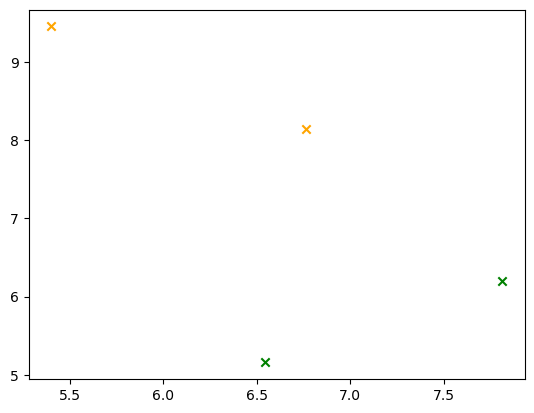

In [352]:
def new_func():
    plt.scatter(x_test[predicted_labels == 0][:,0], marker = 'x', label = 'Predicted Dogs', color = 'green')

plt.scatter(x_test[predicted_labels == 0][:,0], x_test[predicted_labels == 0][:,1], marker='x', label='Predicted Dogs', color='green')

plt.scatter(x_test[predicted_labels == 1][:,0], x_test[predicted_labels == 1][:,1], marker='x', label='Predicted Cats', color='orange')


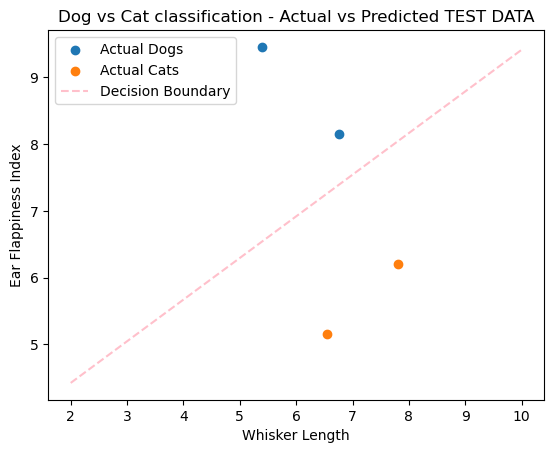

In [353]:
#Plot the actual test data and predicted test data


plt.scatter(x_test[y_test == 0][:,0], x_test[y_test == 0][:, 1], label = 'Actual Dogs')
plt.scatter(x_test[y_test == 1][:,0], x_test[y_test == 1][:, 1], label = 'Actual Cats')

#Plot test data points using decision boundary

predicted_labels = np.zeros_like(y_test)
for m, x_sample in enumerate(x_test):
    if np.dot(best_theta_train, x_sample) + best_theta0_train > 0:
        predicted_labels[m] = 1

#WITHOUT Plotting predicted test data points

#Plot Decision Boundary

plt.plot(x_vals_test, y_vals_test, color ='pink', linestyle = '--', label = 'Decision Boundary')  # type : ignore

plt.xlabel("Whisker Length")
plt.ylabel('Ear Flappiness Index')
plt.title('Dog vs Cat classification - Actual vs Predicted TEST DATA')
plt.legend()
plt.show()